# Tree Edge Weight Distributions Across Geometries

Each child slot is assigned to its nearest parent slot on a given manifold.
The "edge weight" is the geodesic distance of that assignment.
Here we compare these weight distributions across sphere, lorentz, poincaré, and euclidean geometries.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import math

sns.set_theme(style="whitegrid")

DISTS_PATH = Path("videosaur_dino_v1_dists.pt")
dists_all = torch.load(DISTS_PATH, weights_only=False)

MANIFOLDS = [
    "sphere",
    "lorentz_1_exp",
    "lorentz_1_projx",
    "euclidean",
    # --- commented out for easy swap between experiments ---
    # "lorentz_01",
    # "lorentz_05",
    # "lorentz_1",
    # "lorentz_2",
    # "lorentz_5",
    # "poincare_01",
    # "poincare_05",
    # "poincare_1",
    # "poincare_2",
    # "poincare_5",
]

# Read metadata from first video to get P, C
_first_video = sorted(dists_all.keys())[0]
P = dists_all[_first_video]["n_parents"]
C = dists_all[_first_video]["n_children"]
print(f"Parents: {P}, Children: {C}")

# Auto-detect format: (1+P+C) x (1+P+C) with origin vs (P+C) x (P+C) without
_mat_size = dists_all[_first_video][MANIFOLDS[0]].shape[0]
HAS_ORIGIN = _mat_size == 1 + P + C
_O = 1 if HAS_ORIGIN else 0  # offset for origin row/col
print(f"Matrix size: {_mat_size}x{_mat_size} ({'with' if HAS_ORIGIN else 'without'} origin)")

def get_parent_child_dists(video_name, manifold):
    """Extract (P, C) parent-child submatrix."""
    return dists_all[video_name][manifold][_O:_O+P, _O+P:]

def get_child_child_dists(video_name, manifold):
    """Extract (C, C) child-child distance matrix (symmetrized from upper triangle)."""
    cc = dists_all[video_name][manifold][_O+P:, _O+P:]
    return cc + cc.T  # diagonal stays 0

def get_origin_dists(video_name, manifold):
    """Extract distances from origin to all points. Returns (P+C,) vector."""
    assert HAS_ORIGIN, "Origin distances not available in this .pt format"
    return dists_all[video_name][manifold][0, 1:]

# Extract edge weights: for each video/manifold, take the min distance per child
edge_weights = {m: [] for m in MANIFOLDS}

for video_name in sorted(dists_all.keys()):
    for m in MANIFOLDS:
        dist_matrix = get_parent_child_dists(video_name, m)  # (P, C)
        min_dists = dist_matrix.min(dim=0).values  # (C,) — nearest parent distance per child
        edge_weights[m].append(min_dists)

# Stack into arrays: N_videos*C values per manifold
edge_weights = {m: torch.cat(v).numpy() for m, v in edge_weights.items()}

for m in MANIFOLDS:
    print(f"{m:18s}: {len(edge_weights[m])} edges")

Parents: 7, Children: 15
Matrix size: 23x23 (with origin)
sphere            : 4500 edges
lorentz_1_exp     : 4500 edges
lorentz_1_projx   : 4500 edges
euclidean         : 4500 edges


/home/alexpv/anaconda3/envs/tc_clip/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Overlaid KDE plot

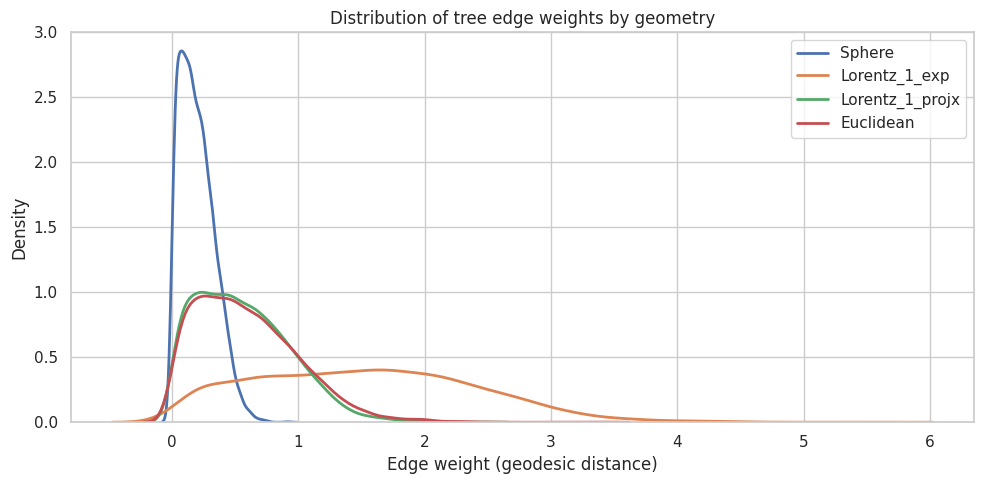

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in MANIFOLDS:
    sns.kdeplot(edge_weights[m], label=m.capitalize(), linewidth=2, ax=ax)

ax.set_xlabel("Edge weight (geodesic distance)")
ax.set_ylabel("Density")
ax.set_title("Distribution of tree edge weights by geometry")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Violin plot

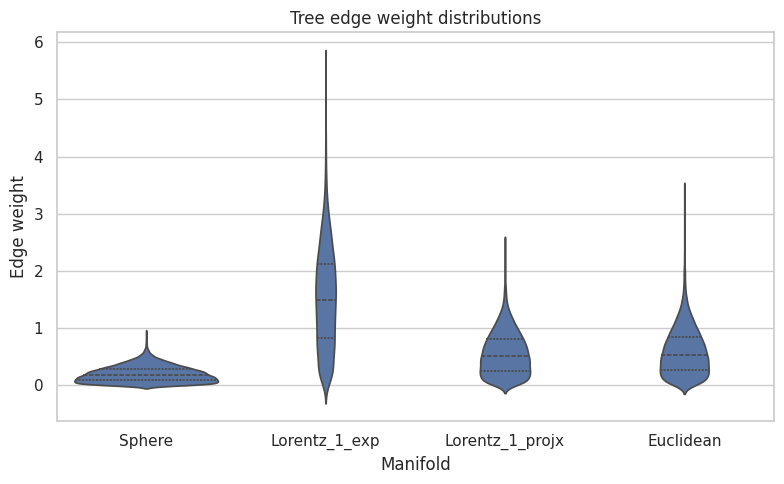

In [3]:
import pandas as pd

df = pd.DataFrame({
    "Edge weight": np.concatenate([edge_weights[m] for m in MANIFOLDS]),
    "Manifold": np.concatenate([[m.capitalize()] * len(edge_weights[m]) for m in MANIFOLDS]),
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="Manifold", y="Edge weight", inner="quart", ax=ax)
ax.set_title("Tree edge weight distributions")
plt.tight_layout()
plt.show()

## 3. Summary statistics

In [4]:
rows = []
for m in MANIFOLDS:
    w = edge_weights[m]
    rows.append({
        "Manifold": m.capitalize(),
        "Mean": f"{w.mean():.4f}",
        "Std": f"{w.std():.4f}",
        "Median": f"{np.median(w):.4f}",
        "Min": f"{w.min():.4f}",
        "Max": f"{w.max():.4f}",
    })

stats_df = pd.DataFrame(rows).set_index("Manifold")
stats_df

,Mean,Std,Median,Min,Max
Manifold,,,,,
Sphere,0.2001,0.1369,0.1788,0.0006,0.9169
Lorentz_1_exp,1.5217,0.8646,1.4966,0.0090,5.5399
Lorentz_1_projx,0.5607,0.3658,0.5141,0.0021,2.4625
Euclidean,0.5937,0.4008,0.5327,0.0022,3.3919


## 4. Pairwise scatter plots

Each point = one child's edge weight in geometry A vs geometry B (4500 points).
Pearson r and Spearman rho annotated on each panel.

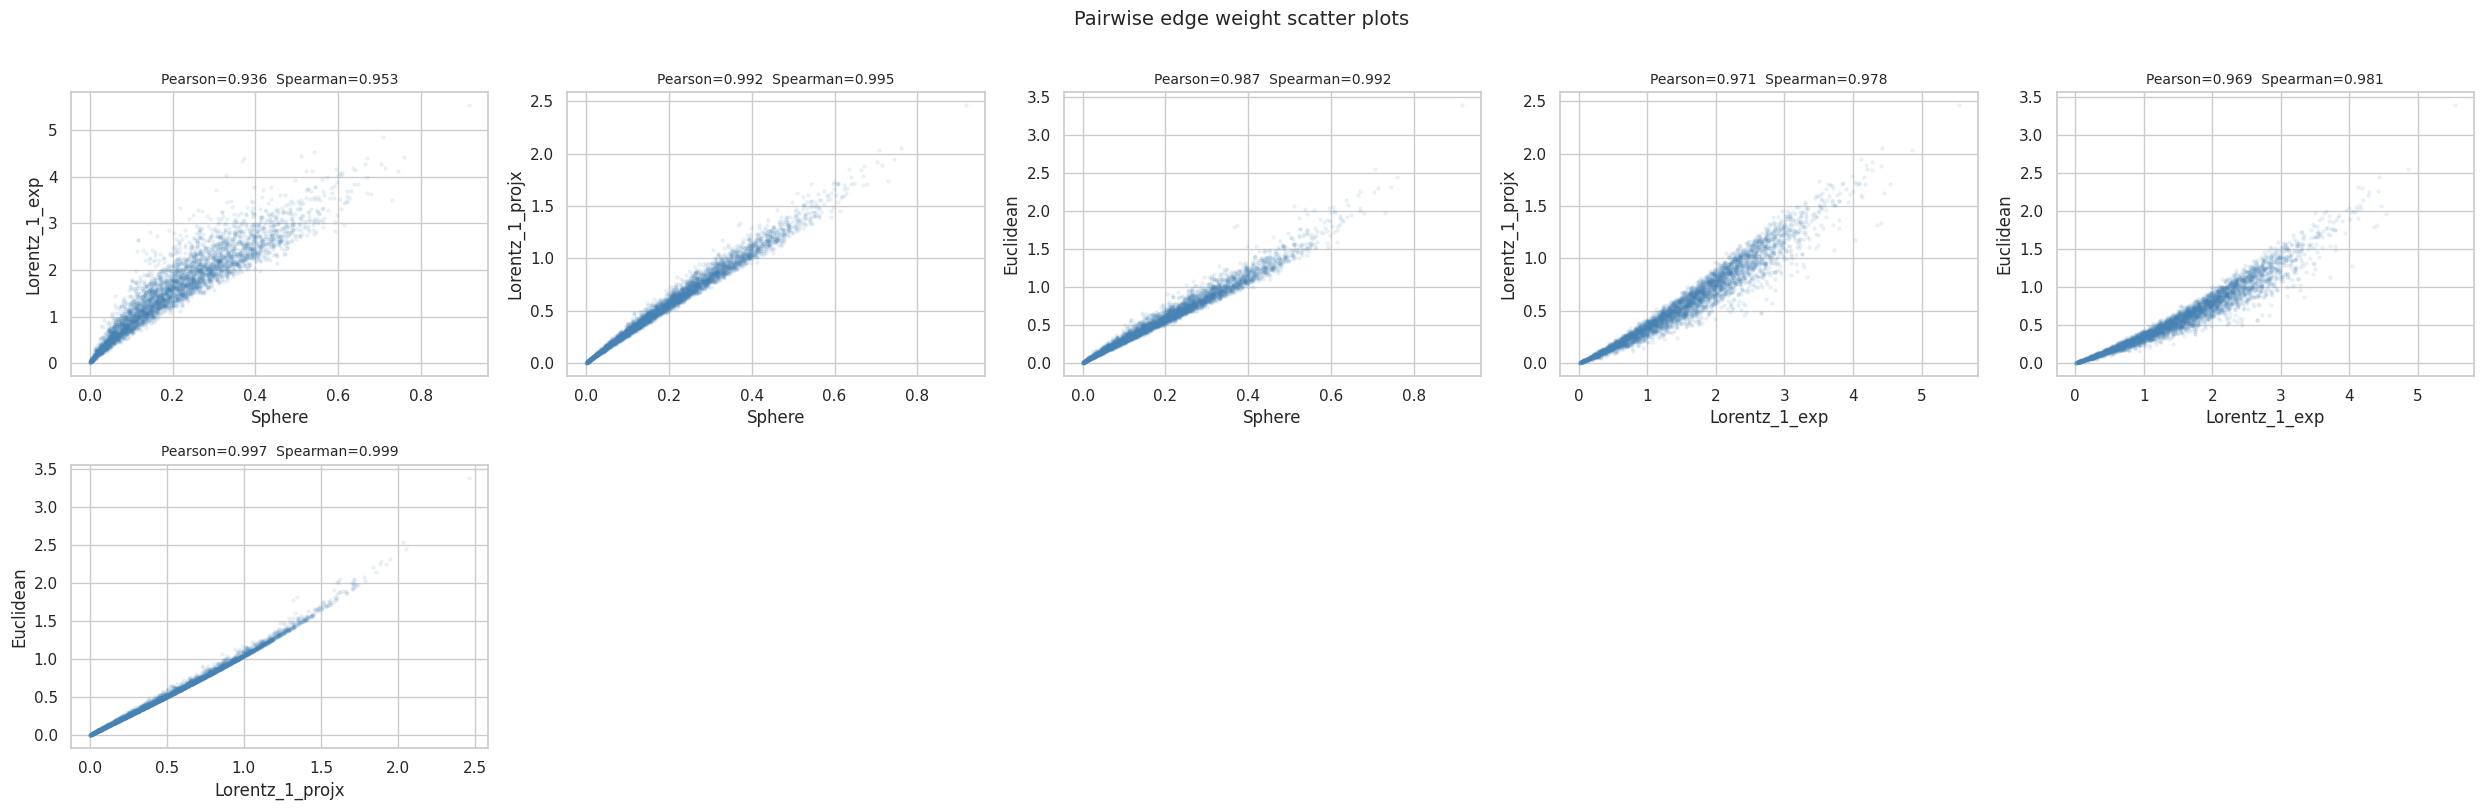

In [5]:
from scipy.stats import spearmanr, pearsonr
from itertools import combinations

pairs = list(combinations(MANIFOLDS, 2))
n_pairs = len(pairs)
ncols = 5
nrows = math.ceil(n_pairs / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, (m1, m2) in enumerate(pairs):
    ax = axes[idx]
    x, y = edge_weights[m1], edge_weights[m2]

    ax.scatter(x, y, alpha=0.08, s=5, color="steelblue", rasterized=True)

    r_pearson, _ = pearsonr(x, y)
    r_spearman, _ = spearmanr(x, y)

    ax.set_xlabel(m1.capitalize())
    ax.set_ylabel(m2.capitalize())
    ax.set_title(f"Pearson={r_pearson:.3f}  Spearman={r_spearman:.3f}", fontsize=10)

# Hide unused subplots
for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Pairwise edge weight scatter plots", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation matrices (Pearson + Spearman)

Global correlations across all 4500 paired edge weights.

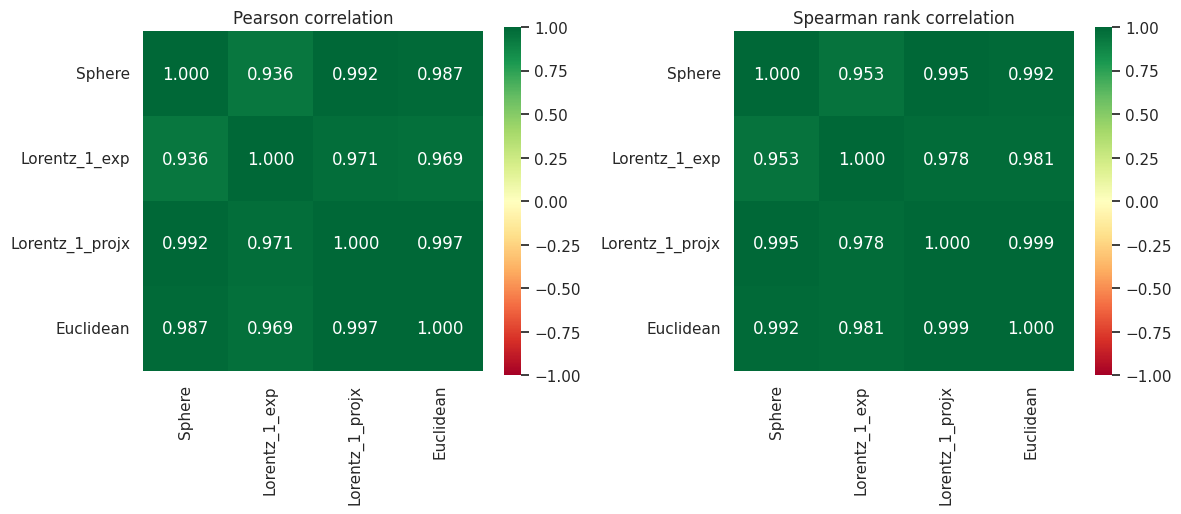

In [6]:
names = [m.capitalize() for m in MANIFOLDS]
n = len(MANIFOLDS)

pearson_mat = np.ones((n, n))
spearman_mat = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            pearson_mat[i, j], _ = pearsonr(edge_weights[MANIFOLDS[i]], edge_weights[MANIFOLDS[j]])
            spearman_mat[i, j], _ = spearmanr(edge_weights[MANIFOLDS[i]], edge_weights[MANIFOLDS[j]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(pearson_mat, annot=True, fmt=".3f", xticklabels=names, yticklabels=names,
            cmap="RdYlGn", vmin=-1, vmax=1, ax=ax1, square=True)
ax1.set_title("Pearson correlation")

sns.heatmap(spearman_mat, annot=True, fmt=".3f", xticklabels=names, yticklabels=names,
            cmap="RdYlGn", vmin=-1, vmax=1, ax=ax2, square=True)
ax2.set_title("Spearman rank correlation")

plt.tight_layout()
plt.show()

## 6. Per-video rank correlation

For each of the 300 videos independently, rank the 15 children by edge weight in each manifold, then compute Spearman correlation between manifold pairs. This isolates *within-video ordering agreement* from global scale differences.

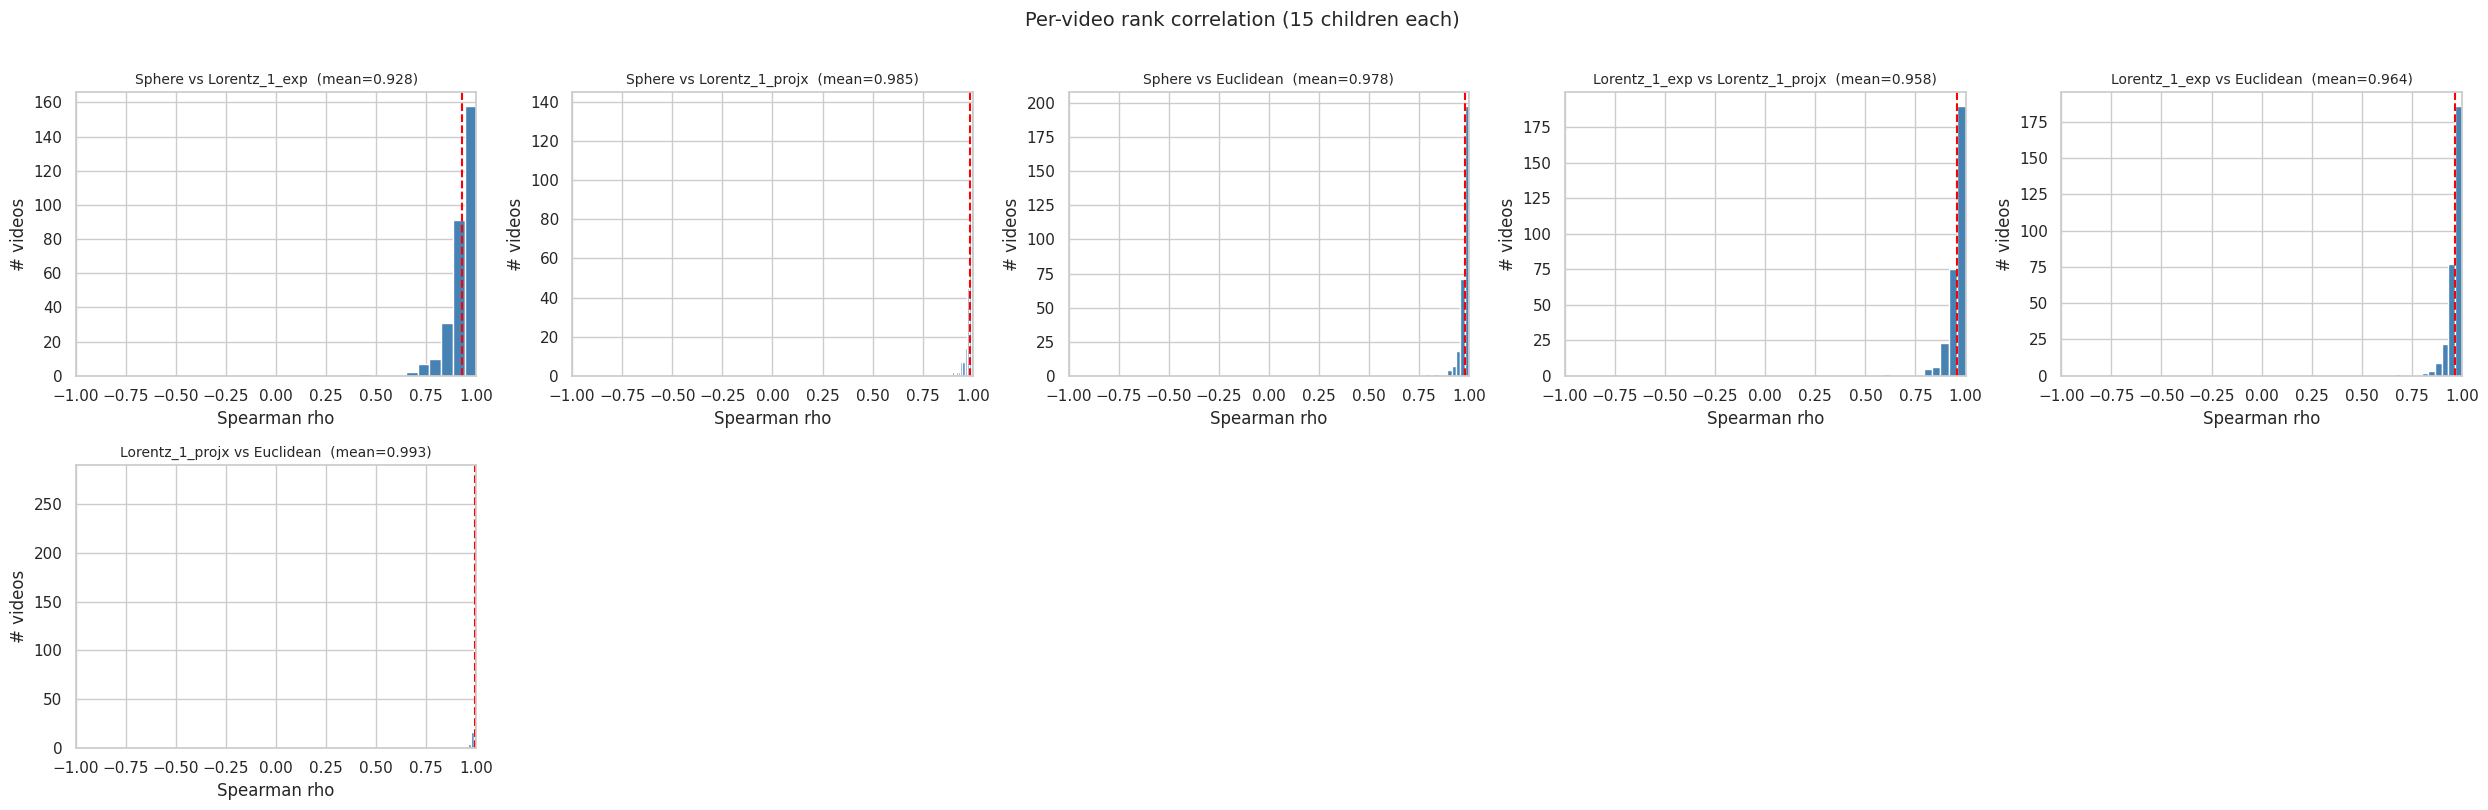

In [7]:
# Rebuild per-video edge weights (lists of C values each)
edge_weights_per_video = {m: [] for m in MANIFOLDS}
video_names = sorted(dists_all.keys())

for vname in video_names:
    for m in MANIFOLDS:
        dm = get_parent_child_dists(vname, m)
        edge_weights_per_video[m].append(dm.min(dim=0).values.numpy())

# Compute per-video Spearman between each pair
per_video_spearman = {(m1, m2): [] for m1, m2 in combinations(MANIFOLDS, 2)}

for vi in range(len(video_names)):
    for m1, m2 in combinations(MANIFOLDS, 2):
        rho, _ = spearmanr(edge_weights_per_video[m1][vi], edge_weights_per_video[m2][vi])
        per_video_spearman[(m1, m2)].append(rho)

# Plot distributions of per-video correlations
pairs = list(combinations(MANIFOLDS, 2))
n_pairs = len(pairs)
ncols = 5
nrows = math.ceil(n_pairs / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, (m1, m2) in enumerate(pairs):
    ax = axes[idx]
    vals = per_video_spearman[(m1, m2)]
    ax.hist(vals, bins=10, color="steelblue", edgecolor="white")
    mean_rho = np.nanmean(vals)
    ax.axvline(mean_rho, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"{m1.capitalize()} vs {m2.capitalize()}  (mean={mean_rho:.3f})", fontsize=10)
    ax.set_xlabel("Spearman rho")
    ax.set_ylabel("# videos")
    ax.set_xlim(-1, 1)

for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Per-video rank correlation (15 children each)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.1 Deep dive: Sphere vs Lorentz disagreements (rho <= 0.75)

Which videos have the lowest rank correlation between Sphere and Lorentz edge weights?

In [8]:
# Sphere vs Lorentz per-video Spearman
sl_rhos = per_video_spearman[("sphere", "lorentz_1_exp")]

# Build a DataFrame of all videos with their rho
sl_df = pd.DataFrame({"video": video_names, "spearman_rho": sl_rhos})
sl_df = sl_df.sort_values("spearman_rho")

# Filter rho <= 0.75
low_agree = sl_df[sl_df["spearman_rho"] <= 0.75].copy()
print(f"Videos with Sphere vs Lorentz rho <= 0.75: {len(low_agree)} / {len(sl_df)}")
print()

# Add parent assignments for sphere and lorentz
sphere_assigns = {}
lorentz_assigns = {}
for vi, vname in enumerate(video_names):
    dm_s = get_parent_child_dists(vname, "sphere")
    dm_l = get_parent_child_dists(vname, "lorentz_1_exp")
    sphere_assigns[vname] = dm_s.argmin(dim=0).tolist()
    lorentz_assigns[vname] = dm_l.argmin(dim=0).tolist()

low_agree["sphere_parents"] = low_agree["video"].map(sphere_assigns)
low_agree["lorentz_parents"] = low_agree["video"].map(lorentz_assigns)

# Count how many children differ in assignment
low_agree["n_disagree"] = low_agree.apply(
    lambda r: sum(s != l for s, l in zip(r["sphere_parents"], r["lorentz_parents"])), axis=1
)

print(low_agree[["video", "spearman_rho", "n_disagree"]].to_string(index=False))
print(f"\nMean disagreeing children: {low_agree['n_disagree'].mean():.1f} / {C}")

Videos with Sphere vs Lorentz rho <= 0.75: 6 / 300

     video  spearman_rho  n_disagree
video_0198      0.414286           0
video_0244      0.696429           1
video_0203      0.703571           0
video_0003      0.728571           0
video_0063      0.746429           0
video_0256      0.750000           2

Mean disagreeing children: 0.5 / 15


In [9]:
# Videos with at least 1 child assigned to a different parent (Sphere vs Lorentz)
all_disagree = []
for vname in video_names:
    s = sphere_assigns[vname]
    l = lorentz_assigns[vname]
    nd = sum(a != b for a, b in zip(s, l))
    if nd >= 1:
        rho = sl_df[sl_df["video"] == vname]["spearman_rho"].values[0]
        all_disagree.append({"video": vname, "spearman_rho": rho, "n_disagree": nd})

disagree_df = pd.DataFrame(all_disagree).sort_values("n_disagree", ascending=False)
print(f"Videos with >= 1 assignment disagreement (Sphere vs Lorentz): {len(disagree_df)} / {len(video_names)}")
print()
print(disagree_df.to_string(index=False))

Videos with >= 1 assignment disagreement (Sphere vs Lorentz): 115 / 300

     video  spearman_rho  n_disagree
video_0191      0.910714           3
video_0141      0.957143           3
video_0258      0.971429           3
video_0107      0.946429           3
video_0135      0.878571           3
video_0248      0.967857           3
video_0088      0.871429           3
video_0256      0.750000           2
video_0252      0.903571           2
video_0213      0.882143           2
video_0216      0.975000           2
video_0153      0.892857           2
video_0239      0.907143           2
video_0238      0.896429           2
video_0234      0.807143           2
video_0119      0.978571           2
video_0210      0.975000           2
video_0211      0.914286           2
video_0268      0.971429           2
video_0011      0.971429           2
video_0175      0.910714           2
video_0164      0.950000           2
video_0035      0.971429           2
video_0014      0.925000           2
vi

### 6.2 Combined metric: agreement-weighted rank correlation

**combined = f_agree x rho_agree**

- `f_agree` = fraction of 15 children assigned to the same parent in both manifolds
- `rho_agree` = Spearman rho computed only over the agreed children's edge weights
- If fewer than 3 children agree, defaults to 0 (Spearman unreliable)

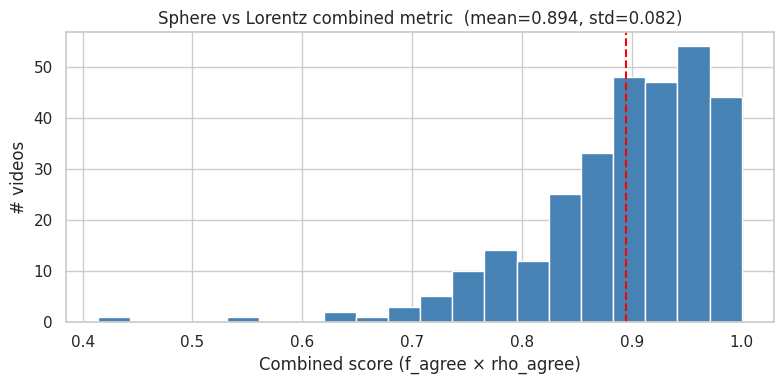

Bottom 10 videos by combined score:

     video  f_agree  rho_agree  combined
video_0198 1.000000   0.414286  0.414286
video_0256 0.866667   0.615385  0.533333
video_0244 0.933333   0.665934  0.621538
video_0135 0.800000   0.804196  0.643357
video_0194 0.933333   0.701099  0.654359
video_0234 0.866667   0.802198  0.695238
video_0203 1.000000   0.703571  0.703571
video_0088 0.800000   0.881119  0.704895
video_0233 0.933333   0.771429  0.720000
video_0213 0.866667   0.835165  0.723810


In [10]:
import math

# Compute combined metric for all 300 videos (Sphere vs Lorentz)
combined_rows = []

for vi, vname in enumerate(video_names):
    s_assign = np.array(sphere_assigns[vname])
    l_assign = np.array(lorentz_assigns[vname])
    agree_mask = s_assign == l_assign

    n_agree = agree_mask.sum()
    f_agree = n_agree / len(s_assign)

    if n_agree >= 3:
        ew_s = edge_weights_per_video["sphere"][vi][agree_mask]
        ew_l = edge_weights_per_video["lorentz_1_exp"][vi][agree_mask]
        rho_agree, _ = spearmanr(ew_s, ew_l)
    else:
        rho_agree = 0.0

    combined = f_agree * rho_agree
    combined_rows.append({
        "video": vname,
        "f_agree": f_agree,
        "rho_agree": rho_agree,
        "combined": combined,
    })

combined_df = pd.DataFrame(combined_rows).sort_values("combined")

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(combined_df["combined"], bins=20, color="steelblue", edgecolor="white")
mean_val = combined_df["combined"].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Combined score (f_agree × rho_agree)")
ax.set_ylabel("# videos")
ax.set_title(f"Sphere vs Lorentz combined metric  (mean={mean_val:.3f}, std={combined_df['combined'].std():.3f})")
plt.tight_layout()
plt.show()

# Bottom 10
print("Bottom 10 videos by combined score:")
print()
print(combined_df.head(10)[["video", "f_agree", "rho_agree", "combined"]].to_string(index=False))

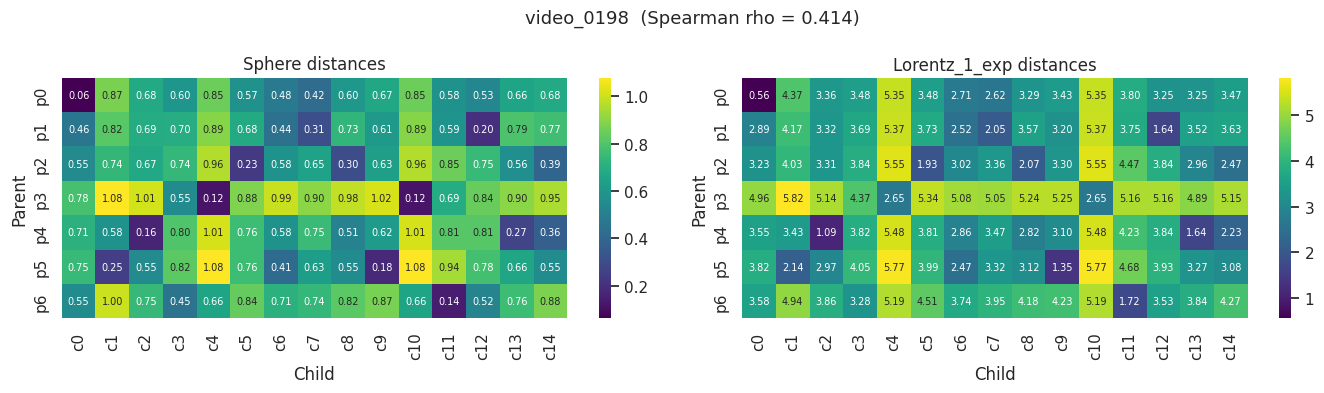

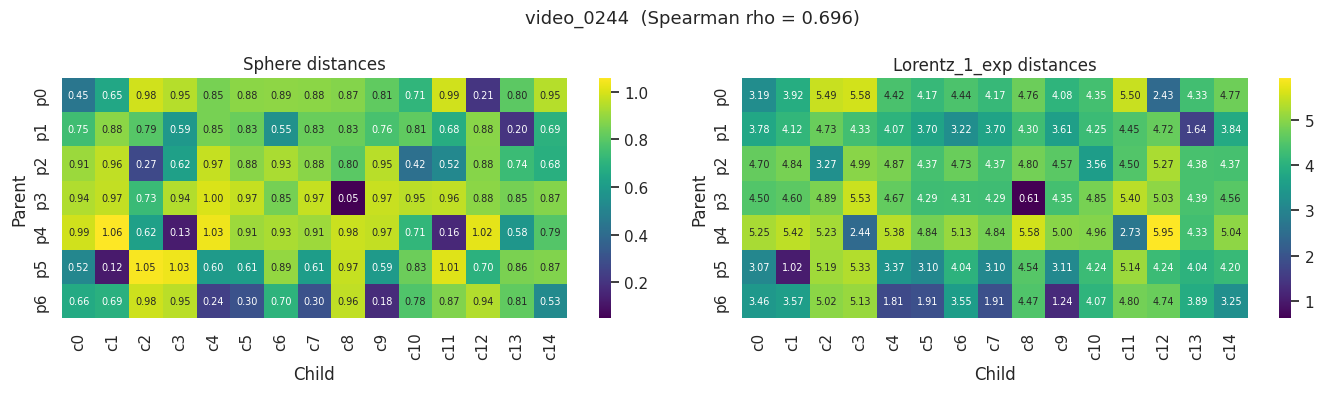

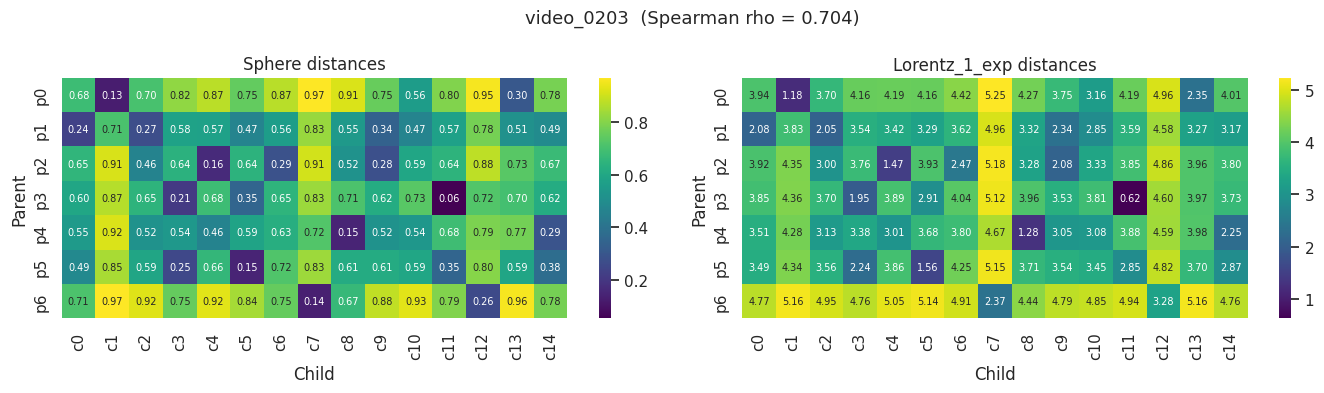

In [11]:
# Side-by-side distance matrix heatmaps for the 3 most disagreeing videos
worst_videos = low_agree.head(3)["video"].tolist()

for vname in worst_videos:
    rho = sl_df[sl_df["video"] == vname]["spearman_rho"].values[0]
    dm_s = get_parent_child_dists(vname, "sphere").numpy()
    dm_l = get_parent_child_dists(vname, "lorentz_1_exp").numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(dm_s, annot=True, fmt=".2f", cmap="viridis", ax=ax1,
                annot_kws={"size": 7},
                xticklabels=[f"c{j}" for j in range(C)],
                yticklabels=[f"p{i}" for i in range(P)])
    ax1.set_title(f"Sphere distances")
    ax1.set_xlabel("Child")
    ax1.set_ylabel("Parent")

    sns.heatmap(dm_l, annot=True, fmt=".2f", cmap="viridis", ax=ax2,
                annot_kws={"size": 7},
                xticklabels=[f"c{j}" for j in range(C)],
                yticklabels=[f"p{i}" for i in range(P)])
    ax2.set_title(f"Lorentz_1_exp distances")
    ax2.set_xlabel("Child")
    ax2.set_ylabel("Parent")

    fig.suptitle(f"{vname}  (Spearman rho = {rho:.3f})", fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Assignment agreement matrix

For each pair of manifolds, what fraction of children are assigned to the **same parent**?

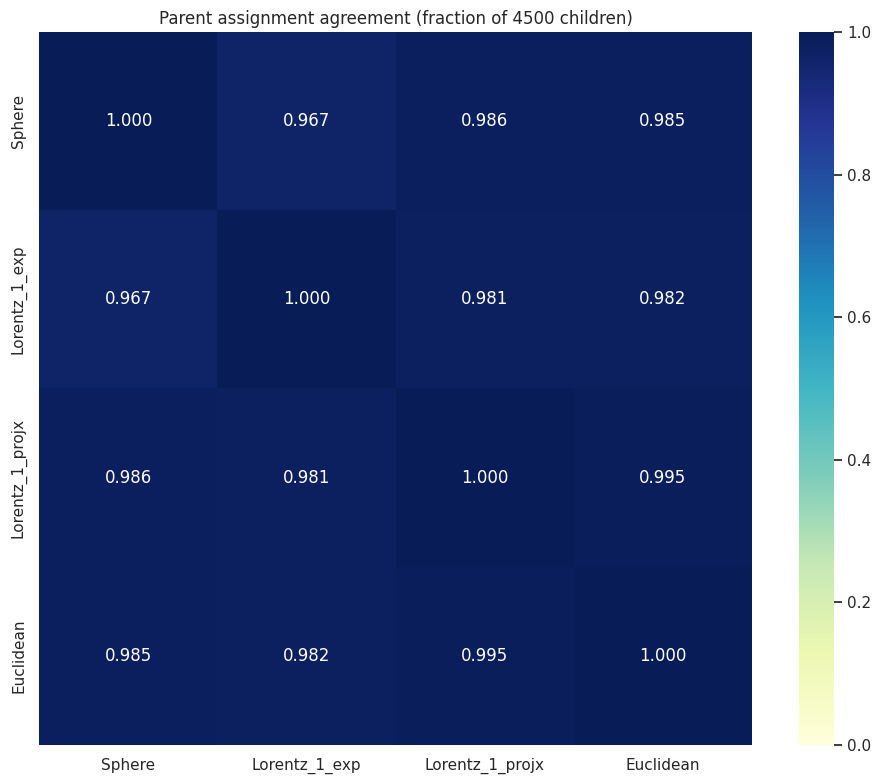

In [12]:
# Build parent assignments: for each video/manifold, which parent was each child assigned to?
assignments = {m: [] for m in MANIFOLDS}

for vname in video_names:
    for m in MANIFOLDS:
        dm = get_parent_child_dists(vname, m)  # (P, C)
        assignments[m].append(dm.argmin(dim=0).numpy())  # (C,)

# Flatten: 300*C assignments per manifold
assignments = {m: np.concatenate(v) for m, v in assignments.items()}

# Agreement matrix
n = len(MANIFOLDS)
agree_mat = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            agree_mat[i, j] = np.mean(assignments[MANIFOLDS[i]] == assignments[MANIFOLDS[j]])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(agree_mat, annot=True, fmt=".3f", xticklabels=names, yticklabels=names,
            cmap="YlGnBu", vmin=0, vmax=1, ax=ax, square=True)
ax.set_title(f"Parent assignment agreement (fraction of {len(video_names)*C} children)")
plt.tight_layout()
plt.show()

## 8. Conditional rank analysis (Lorentz vs Sphere)

Bin children by their Lorentz edge-weight quintile, then show the distribution of their Sphere edge weights (and vice versa). This directly answers: "when Lorentz says a child is far, does Sphere agree?"

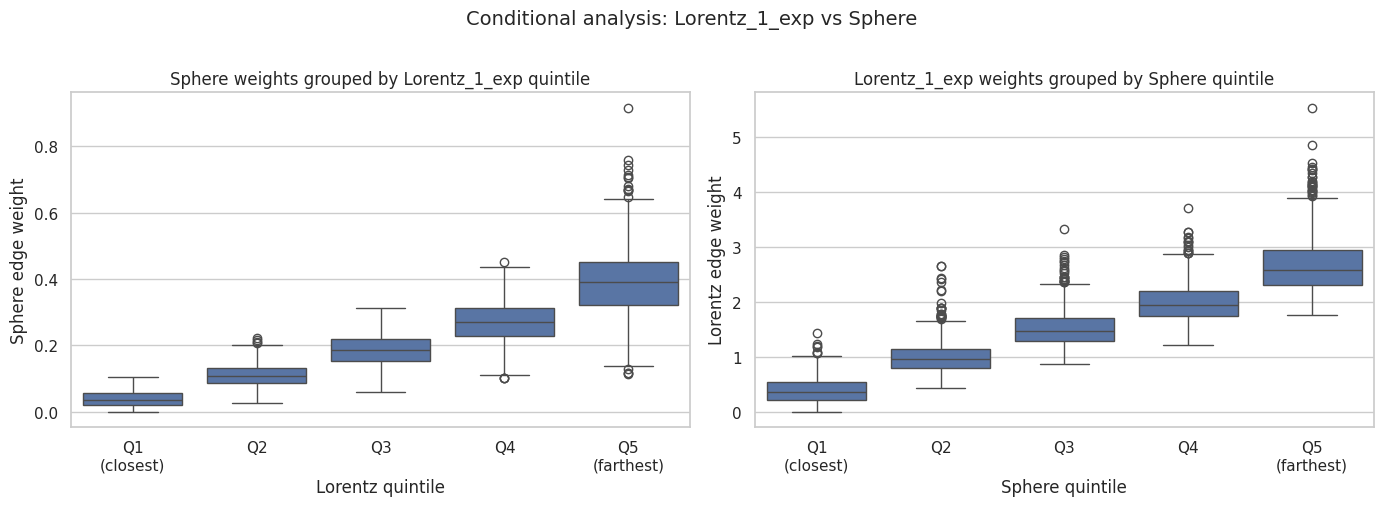

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lorentz quintiles -> Sphere edge weights
lorentz_q = pd.qcut(edge_weights["lorentz_1_exp"], q=5, labels=["Q1\n(closest)", "Q2", "Q3", "Q4", "Q5\n(farthest)"])
cond_df1 = pd.DataFrame({"Lorentz quintile": lorentz_q, "Sphere edge weight": edge_weights["sphere"]})
sns.boxplot(data=cond_df1, x="Lorentz quintile", y="Sphere edge weight", ax=ax1)
ax1.set_title("Sphere weights grouped by Lorentz_1_exp quintile")

# Sphere quintiles -> Lorentz edge weights
sphere_q = pd.qcut(edge_weights["sphere"], q=5, labels=["Q1\n(closest)", "Q2", "Q3", "Q4", "Q5\n(farthest)"])
cond_df2 = pd.DataFrame({"Sphere quintile": sphere_q, "Lorentz edge weight": edge_weights["lorentz_1_exp"]})
sns.boxplot(data=cond_df2, x="Sphere quintile", y="Lorentz edge weight", ax=ax2)
ax2.set_title("Lorentz_1_exp weights grouped by Sphere quintile")

plt.suptitle("Conditional analysis: Lorentz_1_exp vs Sphere", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Distance correlation

Unlike Pearson/Spearman, distance correlation captures arbitrary non-linear dependencies (dcor=0 iff statistically independent).

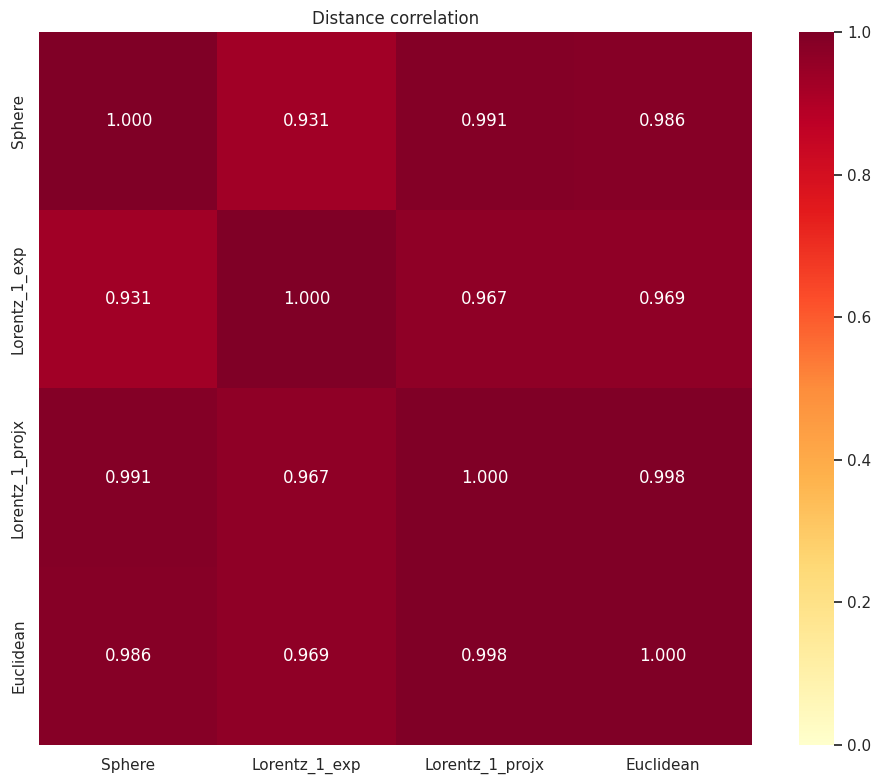

In [14]:
def distance_correlation(x, y):
    """Compute distance correlation between two 1D arrays."""
    n = len(x)
    a = np.abs(x[:, None] - x[None, :])
    b = np.abs(y[:, None] - y[None, :])
    A = a - a.mean(axis=0, keepdims=True) - a.mean(axis=1, keepdims=True) + a.mean()
    B = b - b.mean(axis=0, keepdims=True) - b.mean(axis=1, keepdims=True) + b.mean()
    dcov2 = (A * B).mean()
    dvar_x = (A * A).mean()
    dvar_y = (B * B).mean()
    if dvar_x <= 0 or dvar_y <= 0:
        return 0.0
    return np.sqrt(dcov2 / np.sqrt(dvar_x * dvar_y))

# Subsample for speed (full pairwise distance matrices are O(n^2))
n_edges = len(edge_weights[MANIFOLDS[0]])
rng = np.random.default_rng(42)
idx = rng.choice(n_edges, size=n_edges, replace=False)

dcor_mat = np.ones((n, n))
for i in range(n):
    for j in range(i + 1, n):
        dc = distance_correlation(edge_weights[MANIFOLDS[i]][idx], edge_weights[MANIFOLDS[j]][idx])
        dcor_mat[i, j] = dc
        dcor_mat[j, i] = dc

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dcor_mat, annot=True, fmt=".3f", xticklabels=names, yticklabels=names,
            cmap="YlOrRd", vmin=0, vmax=1, ax=ax, square=True)
ax.set_title("Distance correlation")
plt.tight_layout()
plt.show()

## 10. Hierarchical Quality: Parent vs Sibling Distances

A good hierarchical representation should have children **closer to their assigned parent** than to sibling children (children sharing the same parent).

- **Hierarchical ratio** = `mean(d(child, parent)) / mean(d(sibling, sibling))` per subtree. Ratio < 1 → good hierarchy.
- **Nearest-neighbor violation**: is the nearest parent closer than the nearest sibling? If not, a child is "closer" to another child than to any parent — the tree assignment is fragile.

In [15]:
from itertools import combinations as combs

# For each video/manifold/subtree: compute hierarchical ratio
# ratio = mean(parent-child dists) / mean(sibling-sibling dists)
hier_ratios = {m: [] for m in MANIFOLDS}

for vname in video_names:
    for m in MANIFOLDS:
        pc = get_parent_child_dists(vname, m)   # (P, C)
        cc = get_child_child_dists(vname, m)     # (C, C)
        assigns = pc.argmin(dim=0).numpy()       # (C,) — parent index per child

        for p_idx in range(P):
            child_idxs = np.where(assigns == p_idx)[0]
            if len(child_idxs) < 2:
                continue  # need at least 2 siblings

            # Parent-child distances for this subtree
            pc_dists = pc[p_idx, child_idxs].numpy()

            # Sibling-sibling distances (all pairs)
            sib_dists = []
            for ci, cj in combs(child_idxs, 2):
                sib_dists.append(cc[ci, cj].item())

            ratio = pc_dists.mean() / (np.mean(sib_dists) + 1e-12)
            hier_ratios[m].append(ratio)

for m in MANIFOLDS:
    arr = np.array(hier_ratios[m])
    frac_good = (arr < 1).mean()
    print(f"{m:10s}: {len(arr)} subtrees, "
          f"mean ratio={arr.mean():.3f}, median={np.median(arr):.3f}, "
          f"ratio<1 (good): {frac_good:.1%}")

sphere    : 1376 subtrees, mean ratio=2.291, median=0.572, ratio<1 (good): 94.9%
lorentz_1_exp: 1339 subtrees, mean ratio=1589.957, median=0.657, ratio<1 (good): 94.2%
lorentz_1_projx: 1353 subtrees, mean ratio=1397.140, median=0.592, ratio<1 (good): 94.9%
euclidean : 1357 subtrees, mean ratio=1328.772, median=0.575, ratio<1 (good): 95.0%


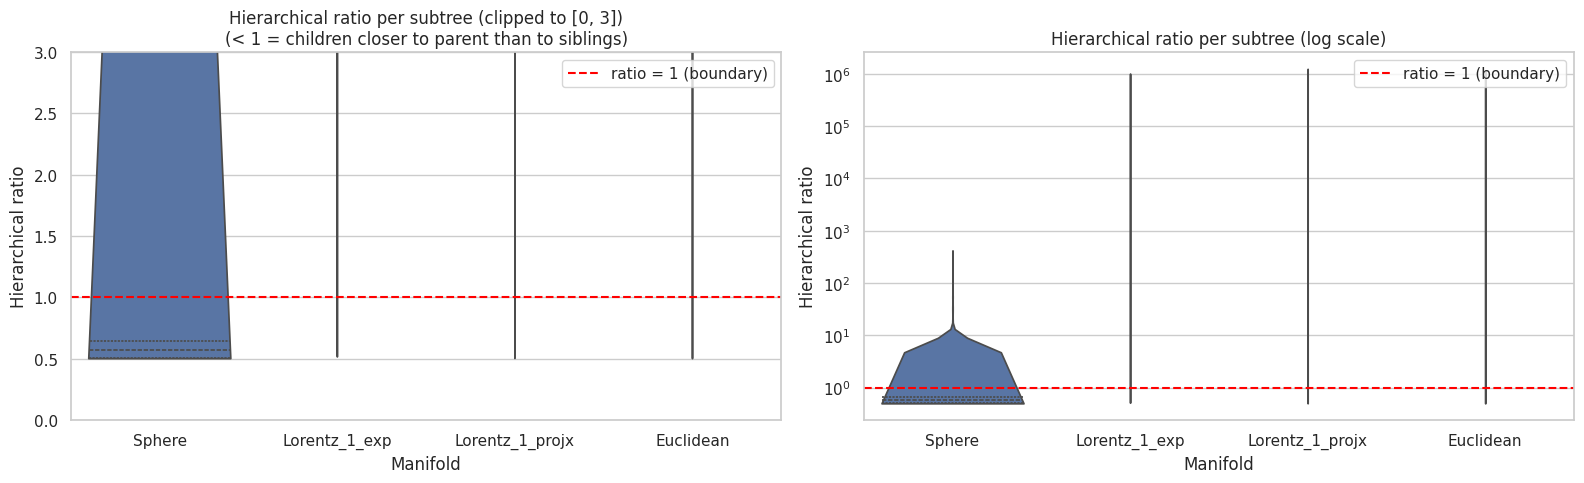

,N subtrees,Mean,Median,P95,Max,% good (< 1)
Manifold,,,,,,
Sphere,1376,2.291,0.572,1.013,419.7,94.9%
Lorentz_1_exp,1339,1589.957,0.657,1.067,1008865.0,94.2%
Lorentz_1_projx,1353,1397.140,0.592,1.011,1240537.3,94.9%
Euclidean,1357,1328.772,0.575,0.993,1156549.7,95.0%


In [16]:
# Violin plot of hierarchical ratios per manifold (clipped to show useful range)
ratio_rows = []
for m in MANIFOLDS:
    for r in hier_ratios[m]:
        ratio_rows.append({"Manifold": m.capitalize(), "Hierarchical ratio": r})

ratio_df = pd.DataFrame(ratio_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: clipped violin
sns.violinplot(data=ratio_df, x="Manifold", y="Hierarchical ratio", inner="quart", ax=ax1, cut=0)
ax1.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="ratio = 1 (boundary)")
ax1.set_ylim(0, 3)
ax1.set_title("Hierarchical ratio per subtree (clipped to [0, 3])\n(< 1 = children closer to parent than to siblings)")
ax1.legend()

# Right: log-scale to see the full range including outliers
sns.violinplot(data=ratio_df, x="Manifold", y="Hierarchical ratio", inner="quart", ax=ax2, cut=0)
ax2.set_yscale("log")
ax2.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="ratio = 1 (boundary)")
ax2.set_title("Hierarchical ratio per subtree (log scale)")
ax2.legend()

plt.tight_layout()
plt.show()

# Summary table
summary_rows = []
for m in MANIFOLDS:
    arr = np.array(hier_ratios[m])
    summary_rows.append({
        "Manifold": m.capitalize(),
        "N subtrees": len(arr),
        "Mean": f"{arr.mean():.3f}",
        "Median": f"{np.median(arr):.3f}",
        "P95": f"{np.percentile(arr, 95):.3f}",
        "Max": f"{arr.max():.1f}",
        "% good (< 1)": f"{(arr < 1).mean():.1%}",
    })
pd.DataFrame(summary_rows).set_index("Manifold")

### 10.1 Nearest neighbor: parent or sibling?

For each child, compare: is the nearest **parent** closer than the nearest **sibling** (other child)?
If the nearest sibling is closer, the tree assignment is fragile — the child has a stronger affinity to another child than to any parent.

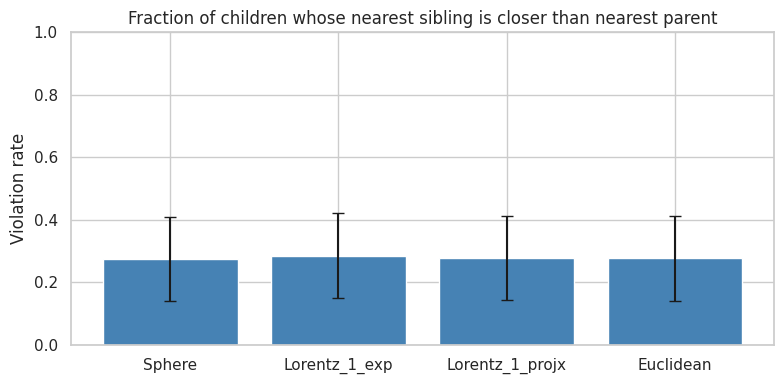

sphere    : mean violation rate = 0.274 +/- 0.135, overall = 0.274
lorentz_1_exp: mean violation rate = 0.284 +/- 0.136, overall = 0.284
lorentz_1_projx: mean violation rate = 0.278 +/- 0.135, overall = 0.278
euclidean : mean violation rate = 0.276 +/- 0.136, overall = 0.276


In [17]:
# For each child: is nearest parent closer than nearest sibling?
violation_rates = {m: [] for m in MANIFOLDS}  # per-video violation rate
per_child_violations = {m: [] for m in MANIFOLDS}  # per-child binary

for vname in video_names:
    for m in MANIFOLDS:
        pc = get_parent_child_dists(vname, m)   # (P, C)
        cc = get_child_child_dists(vname, m)     # (C, C)

        nearest_parent_dist = pc.min(dim=0).values  # (C,)

        # Nearest sibling: min of child-child dists excluding self (diagonal=0)
        cc_masked = cc.clone()
        cc_masked.fill_diagonal_(float("inf"))
        nearest_sibling_dist = cc_masked.min(dim=0).values  # (C,)

        violated = (nearest_sibling_dist < nearest_parent_dist).numpy()
        violation_rates[m].append(violated.mean())
        per_child_violations[m].extend(violated.tolist())

# Bar plot: mean violation rate per manifold
fig, ax = plt.subplots(figsize=(8, 4))
means = [np.mean(violation_rates[m]) for m in MANIFOLDS]
stds = [np.std(violation_rates[m]) for m in MANIFOLDS]
x = range(len(MANIFOLDS))
ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in MANIFOLDS])
ax.set_ylabel("Violation rate")
ax.set_title("Fraction of children whose nearest sibling is closer than nearest parent")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Summary
for m in MANIFOLDS:
    vr = np.array(violation_rates[m])
    print(f"{m:10s}: mean violation rate = {vr.mean():.3f} +/- {vr.std():.3f}, "
          f"overall = {np.mean(per_child_violations[m]):.3f}")

In [18]:
# Worst-case videos: highest violation rate (using first manifold as reference)
ref_m = MANIFOLDS[0]
worst_df = pd.DataFrame({
    "video": video_names,
    **{m: violation_rates[m] for m in MANIFOLDS},
})
worst_df = worst_df.sort_values(ref_m, ascending=False)

print(f"Top 10 videos with highest violation rate ({ref_m}):")
print()
fmt_cols = {m: worst_df[m].map("{:.2f}".format) for m in MANIFOLDS}
display_df = pd.DataFrame({"video": worst_df["video"].values, **{m: fmt_cols[m].values for m in MANIFOLDS}})
print(display_df.head(10).to_string(index=False))

# For the #1 worst video, show per-child detail
worst_video = worst_df.iloc[0]["video"]
print(f"\nDetail for {worst_video} ({ref_m}):")
pc = get_parent_child_dists(worst_video, ref_m)
cc = get_child_child_dists(worst_video, ref_m)
cc_masked = cc.clone()
cc_masked.fill_diagonal_(float("inf"))

nearest_parent_d = pc.min(dim=0).values
nearest_parent_id = pc.argmin(dim=0)
nearest_sibling_d = cc_masked.min(dim=0).values
nearest_sibling_id = cc_masked.argmin(dim=0)

detail_rows = []
for j in range(C):
    violated = nearest_sibling_d[j].item() < nearest_parent_d[j].item()
    detail_rows.append({
        "child": f"c{j}",
        "nearest_parent": f"p{nearest_parent_id[j].item()} ({nearest_parent_d[j].item():.3f})",
        "nearest_sibling": f"c{nearest_sibling_id[j].item()} ({nearest_sibling_d[j].item():.3f})",
        "violated": violated,
    })
print(pd.DataFrame(detail_rows).to_string(index=False))

Top 10 videos with highest violation rate (sphere):

     video sphere lorentz_1_exp lorentz_1_projx euclidean
video_0206   0.67          0.60            0.60      0.67
video_0074   0.60          0.60            0.60      0.60
video_0245   0.60          0.60            0.60      0.60
video_0261   0.60          0.60            0.60      0.60
video_0201   0.53          0.53            0.53      0.53
video_0181   0.53          0.53            0.53      0.53
video_0171   0.53          0.53            0.53      0.53
video_0044   0.53          0.53            0.53      0.53
video_0045   0.53          0.53            0.53      0.53
video_0147   0.53          0.53            0.53      0.53

Detail for video_0206 (sphere):
child nearest_parent nearest_sibling  violated
   c0     p3 (0.021)      c9 (0.498)     False
   c1     p4 (0.025)      c4 (0.000)      True
   c2     p1 (0.408)      c7 (0.484)     False
   c3     p4 (0.024)      c4 (0.000)      True
   c4     p4 (0.025)      c1 (0.000)     

## 11. Distance from Origin

How far are parent and child embeddings from the manifold origin?

- **Lorentz/Poincare**: origin is the natural zero point
- **Euclidean**: origin is (0, 0, ..., 0)
- **Sphere**: origin is the normalized centroid of all projected points

If parents are consistently closer to the origin than children, the representation has a natural "depth" structure where parents sit near the center and children spread outward.

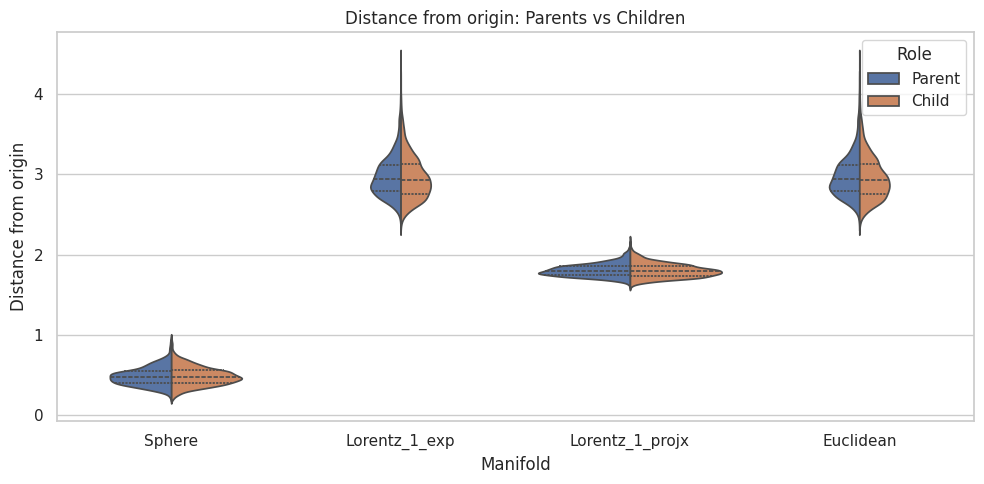

Manifold      Parent mean   Child mean  Parent < Child?
--------------------------------------------------------
sphere             0.4865       0.4871              Yes
lorentz_1_exp       2.9738       2.9578               No
lorentz_1_projx       1.8072       1.8014               No
euclidean          2.9738       2.9578               No


In [19]:
# Distance from origin: parents vs children
origin_parent_dists = {m: [] for m in MANIFOLDS}
origin_child_dists = {m: [] for m in MANIFOLDS}

for vname in video_names:
    for m in MANIFOLDS:
        od = get_origin_dists(vname, m)  # (P+C,)
        origin_parent_dists[m].append(od[:P].numpy())
        origin_child_dists[m].append(od[P:].numpy())

# Build DataFrame for violin plot
rows = []
for m in MANIFOLDS:
    for d in np.concatenate(origin_parent_dists[m]):
        rows.append({"Manifold": m.capitalize(), "Role": "Parent", "Distance from origin": d})
    for d in np.concatenate(origin_child_dists[m]):
        rows.append({"Manifold": m.capitalize(), "Role": "Child", "Distance from origin": d})

origin_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=origin_df, x="Manifold", y="Distance from origin",
               hue="Role", split=True, inner="quart", ax=ax)
ax.set_title("Distance from origin: Parents vs Children")
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Manifold':12s} {'Parent mean':>12s} {'Child mean':>12s} {'Parent < Child?':>16s}")
print("-" * 56)
for m in MANIFOLDS:
    p_mean = np.concatenate(origin_parent_dists[m]).mean()
    c_mean = np.concatenate(origin_child_dists[m]).mean()
    closer = "Yes" if p_mean < c_mean else "No"
    print(f"{m:12s} {p_mean:12.4f} {c_mean:12.4f} {closer:>16s}")

### 11.1 Exploration: expmap0 vs projx projection

Compare how different projection methods affect pairwise distances and distance from origin.
- **expmap0**: maps tangent vector at origin → hyperboloid (preserves radial distance: `dist0 = ||v||`)
- **projx**: orthogonal projection onto hyperboloid (preserves spatial coordinates, different `dist0`)

Sample: video_0000, shape: torch.Size([22, 64])

=== Distance from origin (first 5 parents, first 5 children) ===
Method               Parents (0-4)                            Children (0-4)                          
----------------------------------------------------------------------------------------------------
Sphere               0.505  0.520  0.429  0.470  0.640        0.475  0.700  0.461  0.611  0.365       
Lorentz expmap0      3.255  2.824  2.869  2.965  3.035        2.940  3.221  2.898  3.147  2.695       
Lorentz projx        1.896  1.761  1.776  1.807  1.830        1.799  1.886  1.786  1.864  1.717       
Euclidean            3.255  2.824  2.869  2.965  3.035        2.940  3.221  2.898  3.147  2.695       


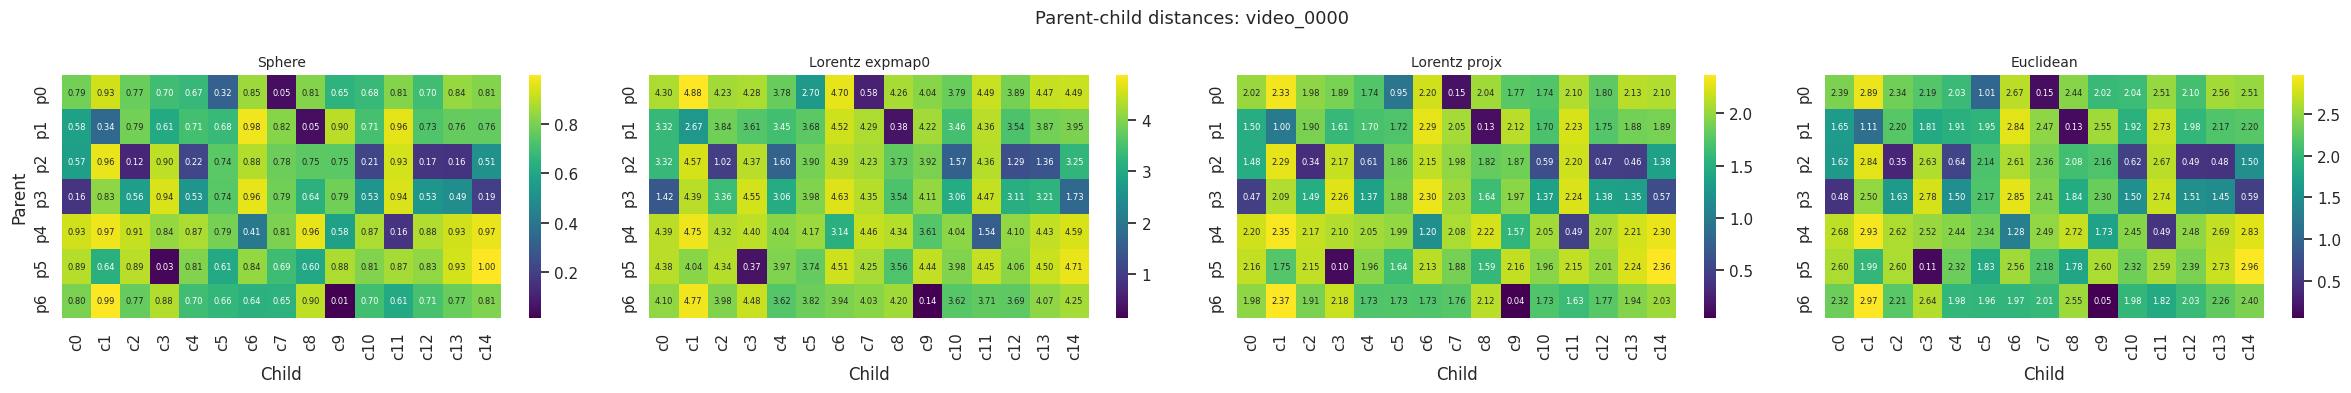


=== Edge weights (min parent dist per child) ===
Child               Sphere     Lorentz expmap0       Lorentz projx           Euclidean
c0                  0.1617              1.4206              0.4726              0.4776
c1                  0.3436              2.6651              0.9971              1.1052
c2                  0.1197              1.0214              0.3434              0.3462
c3                  0.0321              0.3652              0.1012              0.1098
c4                  0.2208              1.6041              0.6063              0.6370
c5                  0.3150              2.7024              0.9491              1.0118
c6                  0.4120              3.1390              1.2008              1.2829
c7                  0.0452              0.5829              0.1475              0.1491
c8                  0.0458              0.3829              0.1293              0.1295
c9                  0.0137              0.1425              0.0420              

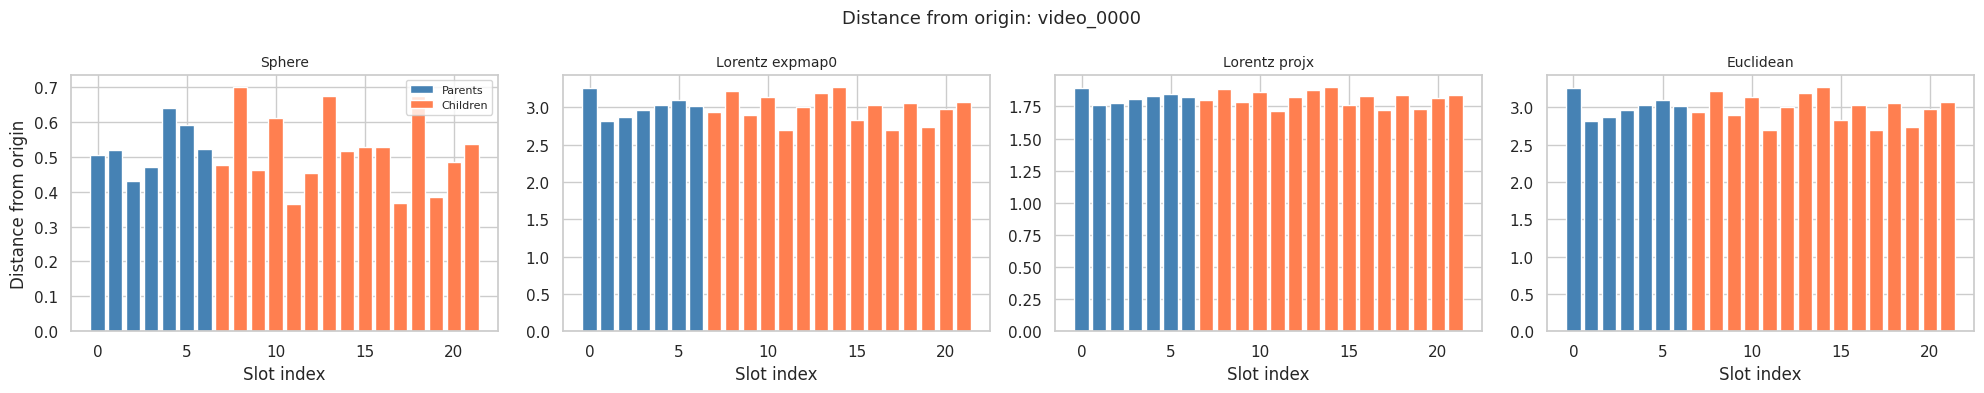

In [20]:
import sys
sys.path.insert(0, str(Path(".").resolve()))
from hyperbolic_tree import project_to_manifold, pairwise_distances, dist_from_origin, MANIFOLD_REGISTRY
import torch.nn.functional as F

# Load one video's raw embeddings
sample_video = sorted(dists_all.keys())[0]
vdir = Path("/home/alexpv/Default_Folder/notes/phd/1-projects/videosaur-dino-v1") / sample_video
parents_raw = torch.load(vdir / "slots_raw_7.pt", weights_only=True)[-1].double()
children_raw = torch.load(vdir / "slots_raw_15.pt", weights_only=True)[-1].double()
all_raw = torch.cat([parents_raw, children_raw], dim=0)  # (22, 64)
print(f"Sample: {sample_video}, shape: {all_raw.shape}")

manifold_lor = MANIFOLD_REGISTRY["lorentz_1_exp"].to(dtype=all_raw.dtype)
m_sphere = MANIFOLD_REGISTRY["sphere"].to(dtype=all_raw.dtype)
m_euc = MANIFOLD_REGISTRY["euclidean"].to(dtype=all_raw.dtype)

projs = {
    "Sphere":           (m_sphere,      project_to_manifold(all_raw, m_sphere)),
    "Lorentz expmap0":  (manifold_lor,  project_to_manifold(all_raw, manifold_lor, method="expmap0")),
    "Lorentz projx":    (manifold_lor,  project_to_manifold(all_raw, manifold_lor, method="projx")),
    "Euclidean":        (m_euc,         all_raw.clone()),
}

# --- Distance from origin ---
print("\n=== Distance from origin (first 5 parents, first 5 children) ===")
print(f"{'Method':<20s} {'Parents (0-4)':<40s} {'Children (0-4)':<40s}")
print("-" * 100)
for label, (manifold, pts) in projs.items():
    od = dist_from_origin(pts, manifold)
    p_str = "  ".join(f"{od[i].item():.3f}" for i in range(5))
    c_str = "  ".join(f"{od[P+i].item():.3f}" for i in range(5))
    print(f"{label:<20s} {p_str:<40s} {c_str:<40s}")

# --- Pairwise parent-child distances ---
fig, axes = plt.subplots(1, 4, figsize=(24, 4))
for idx, (label, (manifold, pts)) in enumerate(projs.items()):
    pw = pairwise_distances(pts, pts, manifold)
    pc = pw[:P, P:].detach().numpy()
    ax = axes[idx]
    sns.heatmap(pc, annot=True, fmt=".2f", cmap="viridis", ax=ax,
                annot_kws={"size": 6},
                xticklabels=[f"c{j}" for j in range(C)],
                yticklabels=[f"p{i}" for i in range(P)])
    ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("Child")
    if idx == 0:
        ax.set_ylabel("Parent")

fig.suptitle(f"Parent-child distances: {sample_video}", fontsize=13)
plt.tight_layout()
plt.show()

# --- Edge weights comparison ---
print("\n=== Edge weights (min parent dist per child) ===")
print(f"{'Child':<6s}", end="")
for label in projs:
    print(f"{label:>20s}", end="")
print()
for j in range(C):
    print(f"c{j:<5d}", end="")
    for label, (manifold, pts) in projs.items():
        pw = pairwise_distances(pts, pts, manifold)
        ew = pw[:P, P+j].min().item()
        print(f"{ew:>20.4f}", end="")
    print()

# --- Origin distance: parents vs children per method ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for idx, (label, (manifold, pts)) in enumerate(projs.items()):
    od = dist_from_origin(pts, manifold).detach().numpy()
    ax = axes[idx]
    ax.bar(range(P), od[:P], color="steelblue", label="Parents")
    ax.bar(range(P, P+C), od[P:], color="coral", label="Children")
    ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("Slot index")
    if idx == 0:
        ax.set_ylabel("Distance from origin")
        ax.legend(fontsize=8)

fig.suptitle(f"Distance from origin: {sample_video}", fontsize=13)
plt.tight_layout()
plt.show()